In [5]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("/content/Ecommerce_Delivery_Analytics_New.csv")
df.info()

df.isnull().sum()

df.duplicated().sum()

df.drop_duplicates(inplace=True)

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Order ID                 100000 non-null  object
 1   Customer ID              100000 non-null  object
 2   Platform                 100000 non-null  object
 3   Delivery Time (Minutes)  100000 non-null  int64 
 4   Product Category         100000 non-null  object
 5   Order Value (INR)        100000 non-null  int64 
 6   Customer Feedback        100000 non-null  object
 7   Service Rating           100000 non-null  int64 
 8   Delivery Delay           100000 non-null  object
 9   Refund Requested         100000 non-null  object
dtypes: int64(3), object(7)
memory usage: 7.6+ MB


,Delivery Time (Minutes),Order Value (INR),Service Rating
count,100000.000000,100000.000000,100000.000000
mean,29.536140,590.994400,3.240790
std,9.958933,417.409058,1.575962
min,5.000000,50.000000,1.000000
25%,23.000000,283.000000,2.000000
50%,30.000000,481.000000,3.000000
75%,36.000000,770.000000,5.000000
max,76.000000,2000.000000,5.000000


In [9]:

df.head()

def Feedback_category(feedback):
  if feedback=="Good quality products." or feedback=="Easy to order, loved it!":
    return"Good"
  elif feedback=="Quick and reliable!" or feedback=="Packaging could be better.":
    return"Average"
  elif feedback=="Fast delivery, great service!" or feedback=="Very satisfied with the service." or feedback=="Excellent experience!":
    return"Excellent"
  else:
    return"Worst"
df["Feedback_category"]=df['Customer Feedback'].apply(Feedback_category)
df.info()
df.head()

def rating_category(rating):
  if rating>=4:
    return"High"
  elif rating>=2 and rating<4:
    return"Medium"
  else:
    return"Low"
df["Rating_Category"]=df['Service Rating'].apply(rating_category)
df


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Order ID                 100000 non-null  object
 1   Customer ID              100000 non-null  object
 2   Platform                 100000 non-null  object
 3   Delivery Time (Minutes)  100000 non-null  int64 
 4   Product Category         100000 non-null  object
 5   Order Value (INR)        100000 non-null  int64 
 6   Customer Feedback        100000 non-null  object
 7   Service Rating           100000 non-null  int64 
 8   Delivery Delay           100000 non-null  object
 9   Refund Requested         100000 non-null  object
 10  Feedback_category        100000 non-null  object
dtypes: int64(3), object(8)
memory usage: 8.4+ MB


,Order ID,Customer ID,Platform,Delivery Time (Minutes),Product Category,Order Value (INR),Customer Feedback,Service Rating,Delivery Delay,Refund Requested,Feedback_category,Rating_Category
0,ORD000001,CUST2824,JioMart,30,Fruits & Vegetables,382,"Fast delivery, great service!",5,No,No,Excellent,High
1,ORD000002,CUST1409,Blinkit,16,Dairy,279,Quick and reliable!,5,No,No,Average,High
2,ORD000003,CUST5506,JioMart,25,Beverages,599,Items missing from order.,2,No,Yes,Worst,Medium
3,ORD000004,CUST5012,JioMart,42,Beverages,946,Items missing from order.,2,Yes,Yes,Worst,Medium
4,ORD000005,CUST4657,Blinkit,30,Beverages,334,"Fast delivery, great service!",5,No,No,Excellent,High
...,...,...,...,...,...,...,...,...,...,...,...,...
99995,ORD099996,CUST5324,JioMart,24,Dairy,289,Packaging could be better.,3,No,No,Average,Medium
99996,ORD099997,CUST1677,JioMart,19,Snacks,322,Good quality products.,4,No,No,Good,High
99997,ORD099998,CUST8198,JioMart,41,Dairy,135,"Fast delivery, great service!",5,Yes,No,Excellent,High
99998,ORD099999,CUST9975,JioMart,31,Grocery,973,Quick and reliable!,5,No,No,Average,High


In [13]:
#most selling product from  platforms
most_selling=(df.groupby(["Platform","Product Category"]).size().reset_index(name="count"))
most=most_selling.loc[most_selling.groupby('Platform')['count'].idxmax()]
#fastest delivered patform
fast= (df.groupby('Platform')['Delivery Time (Minutes)'] .mean().idxmin())
#higest order value platform
highest_order_platform=(df.groupby('Platform')['Order Value (INR)'].sum().idxmax())
#most excellent feedback from a platform
mosts=(df[df['Feedback_category']=="Excellent"].groupby('Platform').size().idxmax())
#most delivery delayed by a platform
delay=(df[df['Delivery Delay']=="Yes"].groupby('Platform').size().idxmax())
#most refund request by platform
returns=(df[df['Refund Requested']=="Yes"].groupby('Platform').size().idxmax())
# highest service rating for a platform
highest_service=(df[df['Rating_Category']=='High'].groupby('Platform').size().idxmax())
# lowest service rating for a platform
lowest_service=(df[df['Rating_Category']=='Low'].groupby('Platform').size().idxmax())
#most selled product
most_selled_product=df['Product Category'].value_counts().idxmax()
#total orders of each platform
platforms=df.groupby('Platform')['Order Value (INR)'].sum()
#most repeated customer and product he buys
customer=df['Customer ID'].value_counts().idxmax()
product_he_buys=(df[df['Customer ID']==customer].groupby('Product Category').size().idxmax())




In [23]:
summary = {

    "Fastest Delivered Platform": [fast],
    "Highest Order Value Platform": [highest_order_platform],
    "Most Excellent Feedback Platform": [mosts],
    "Most Delivery Delayed Platform": [delay],
    "Most Refund Requests Platform": [returns],
    "Highest Service Rating Platform": [highest_service],
    "Lowest Service Rating Platform": [lowest_service],
    "Most Sold Product": [most_selled_product],
    "Most Repeated Customer": [customer],
    "Most Purchased Product by Repeat Customer": [product_he_buys]
}

summary_df = pd.DataFrame(summary)
print("Business Summary")
display(summary_df)

print("Most Selling Product by Platform")
display(most)


Business Summary


,Fastest Delivered Platform,Highest Order Value Platform,Most Excellent Feedback Platform,Most Delivery Delayed Platform,Most Refund Requests Platform,Highest Service Rating Platform,Lowest Service Rating Platform,Most Sold Product,Most Repeated Customer,Most Purchased Product by Repeat Customer
0,Blinkit,Swiggy Instamart,Swiggy Instamart,Swiggy Instamart,Blinkit,Swiggy Instamart,Blinkit,Dairy,CUST8779,Fruits & Vegetables


Most Selling Product by Platform


,Platform,Product Category,count
1,Blinkit,Dairy,5643
9,JioMart,Grocery,5605
16,Swiggy Instamart,Personal Care,5634


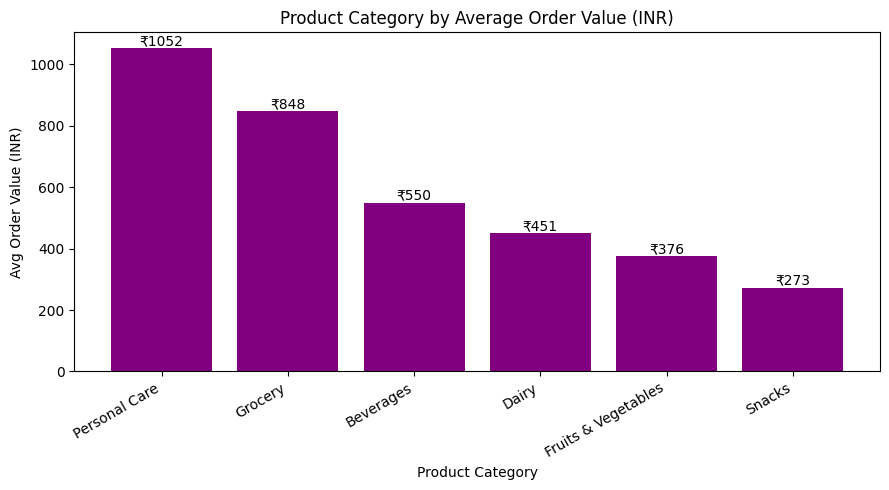

In [12]:



# --- Chart 1: Average Order Value by Product Category ---
products = df.groupby('Product Category')['Order Value (INR)'].mean().sort_values(ascending=False)
plt.figure(figsize=(9, 5))
bars = plt.bar(products.index, products.values, color="purple")
plt.xlabel('Product Category')
plt.ylabel("Avg Order Value (INR)")
plt.title("Product Category by Average Order Value (INR)")
plt.xticks(rotation=30, ha='right')
plt.bar_label(bars, fmt='₹%.0f')
plt.tight_layout()

plt.show()





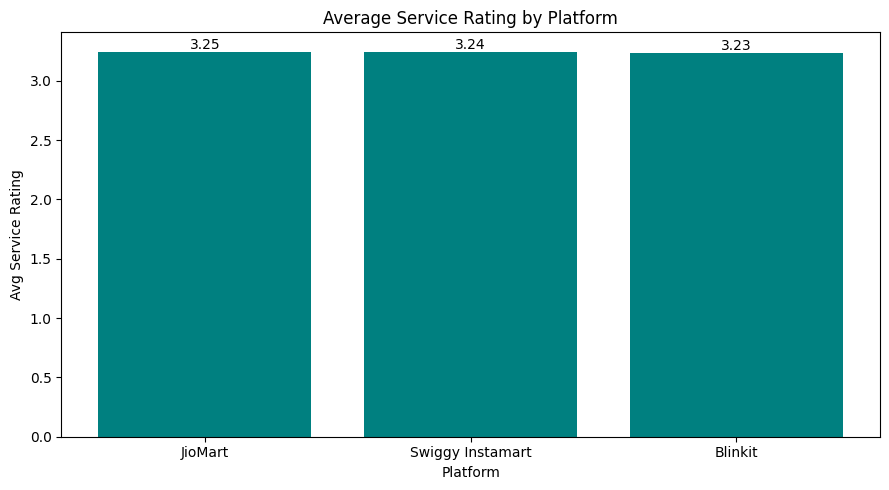

In [13]:
# --- Chart 2: Average Service Rating by Platform ---
service_rating_by_platform = df.groupby('Platform')['Service Rating'].mean().sort_values(ascending=False)
plt.figure(figsize=(9, 5))
bars1 = plt.bar(service_rating_by_platform.index, service_rating_by_platform.values, color="teal")
plt.xlabel('Platform')
plt.ylabel('Avg Service Rating')
plt.title('Average Service Rating by Platform')
plt.bar_label(bars1, fmt='%.2f')
plt.tight_layout()

plt.show()

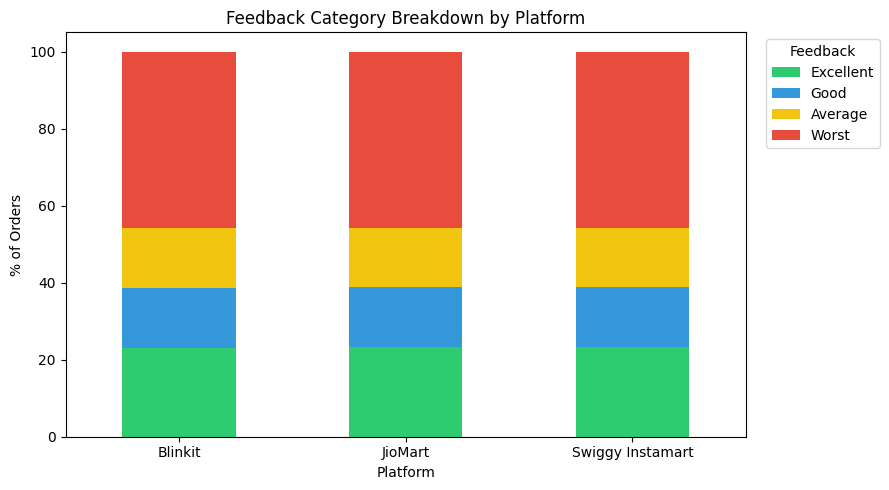

In [14]:
# --- Chart 3: Feedback Category Breakdown by Platform (stacked, % of orders) ---
feedback_ct = pd.crosstab(df['Platform'], df['Feedback_category'], normalize='index') * 100
feedback_ct = feedback_ct[['Excellent', 'Good', 'Average', 'Worst']]
feedback_ct.plot(kind='bar', stacked=True, figsize=(9, 5),
                  color=['#2ecc71', '#3498db', '#f1c40f', '#e74c3c'])
plt.xlabel('Platform')
plt.ylabel('% of Orders')
plt.title('Feedback Category Breakdown by Platform')
plt.xticks(rotation=0)
plt.legend(title='Feedback', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

plt.show()

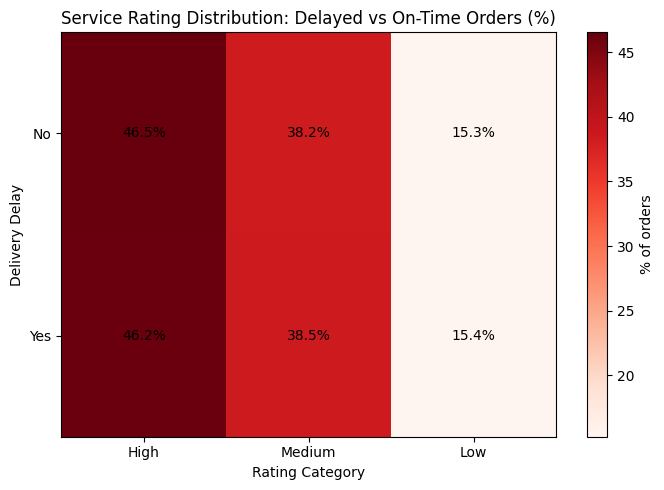

In [15]:
# --- Chart 4: Does delivery delay predict low service rating? (heatmap) ---
delay_vs_rating = pd.crosstab(df['Delivery Delay'], df['Rating_Category'], normalize='index') * 100
delay_vs_rating = delay_vs_rating[['High', 'Medium', 'Low']]
plt.figure(figsize=(7, 5))
im = plt.imshow(delay_vs_rating.values, cmap='Reds', aspect='auto')
plt.xticks(range(len(delay_vs_rating.columns)), delay_vs_rating.columns)
plt.yticks(range(len(delay_vs_rating.index)), delay_vs_rating.index)
plt.xlabel('Rating Category')
plt.ylabel('Delivery Delay')
plt.title('Service Rating Distribution: Delayed vs On-Time Orders (%)')
for i in range(delay_vs_rating.shape[0]):
    for j in range(delay_vs_rating.shape[1]):
        plt.text(j, i, f"{delay_vs_rating.values[i, j]:.1f}%", ha='center', va='center')
plt.colorbar(im, label='% of orders')
plt.tight_layout()

plt.show()

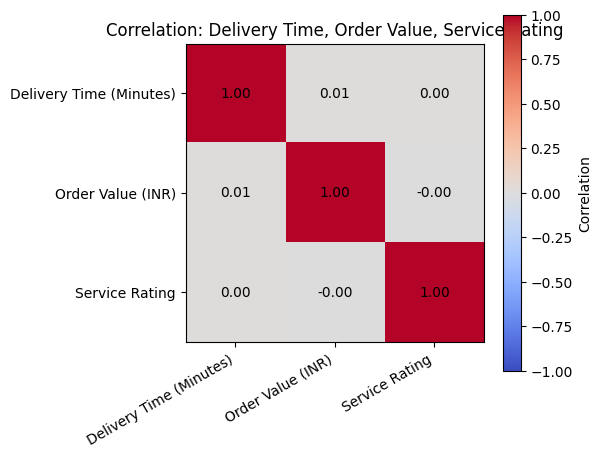

In [16]:
# --- Chart 5: Correlation heatmap of numeric variables ---
numeric_cols = df[['Delivery Time (Minutes)', 'Order Value (INR)', 'Service Rating']]
corr = numeric_cols.corr()
plt.figure(figsize=(6, 5))
im = plt.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=30, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation: Delivery Time, Order Value, Service Rating')
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        plt.text(j, i, f"{corr.values[i, j]:.2f}", ha='center', va='center')
plt.colorbar(im, label='Correlation')
plt.tight_layout()

plt.show()

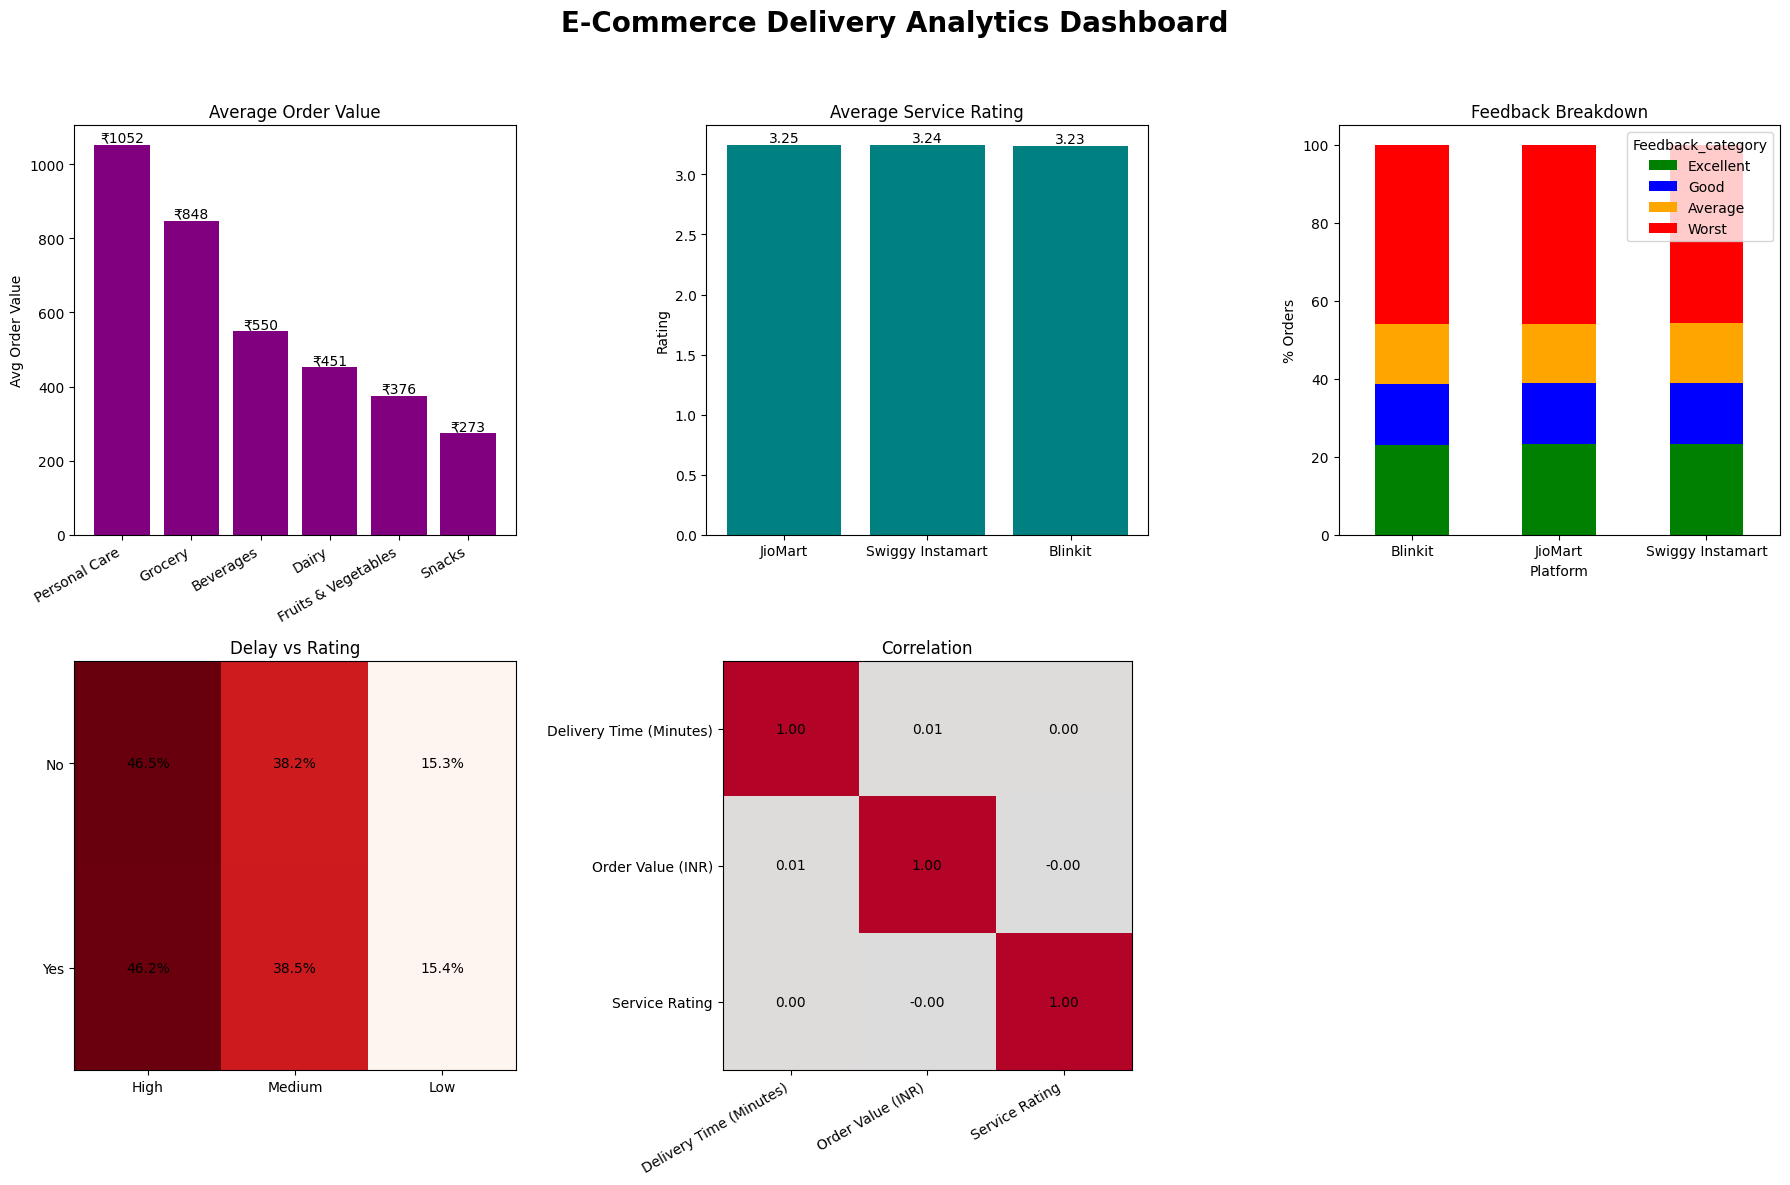

In [39]:
import matplotlib.pyplot as plt




# Create Dashboard
fig = plt.figure(figsize=(18, 12))
fig.suptitle("E-Commerce Delivery Analytics Dashboard", fontsize=20, fontweight="bold")



# ---------------- Chart 1 ----------------
plt.subplot(2,3,1)

products = df.groupby('Product Category')['Order Value (INR)'].mean().sort_values(ascending=False)

bars = plt.bar(products.index, products.values, color="purple")
plt.title("Average Order Value")
plt.xticks(rotation=30, ha='right')
plt.ylabel("Avg Order Value")
plt.bar_label(bars, fmt='₹%.0f')

# ---------------- Chart 2 ----------------
plt.subplot(2,3,2)

service_rating_by_platform = df.groupby('Platform')['Service Rating'].mean().sort_values(ascending=False)

bars1 = plt.bar(service_rating_by_platform.index,
                service_rating_by_platform.values,
                color="teal")

plt.title("Average Service Rating")
plt.ylabel("Rating")
plt.bar_label(bars1, fmt="%.2f")

# ---------------- Chart 3 ----------------
plt.subplot(2,3,3)

feedback_ct = pd.crosstab(
    df['Platform'],
    df['Feedback_category'],
    normalize='index'
) * 100

feedback_ct = feedback_ct[['Excellent','Good','Average','Worst']]

feedback_ct.plot(
    kind='bar',
    stacked=True,
    ax=plt.gca(),
    color=['green','blue','orange','red']
)

plt.title("Feedback Breakdown")
plt.ylabel("% Orders")
plt.xticks(rotation=0)

# ---------------- Chart 4 ----------------
plt.subplot(2,3,4)

delay_vs_rating = pd.crosstab(
    df['Delivery Delay'],
    df['Rating_Category'],
    normalize='index'
) * 100

delay_vs_rating = delay_vs_rating[['High','Medium','Low']]

im = plt.imshow(delay_vs_rating.values,
                cmap="Reds",
                aspect='auto')

plt.xticks(range(len(delay_vs_rating.columns)),
           delay_vs_rating.columns)

plt.yticks(range(len(delay_vs_rating.index)),
           delay_vs_rating.index)

plt.title("Delay vs Rating")

for i in range(delay_vs_rating.shape[0]):
    for j in range(delay_vs_rating.shape[1]):
        plt.text(j, i,
                 f"{delay_vs_rating.values[i,j]:.1f}%",
                 ha='center',
                 va='center')

# ---------------- Chart 5 ----------------
plt.subplot(2,3,5)

numeric_cols = df[['Delivery Time (Minutes)',
                   'Order Value (INR)',
                   'Service Rating']]

corr = numeric_cols.corr()

im = plt.imshow(corr.values,
                cmap='coolwarm',
                vmin=-1,
                vmax=1)

plt.xticks(range(len(corr.columns)),
           corr.columns,
           rotation=30,
           ha='right')

plt.yticks(range(len(corr.columns)),
           corr.columns)

plt.title("Correlation")

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        plt.text(j,
                 i,
                 f"{corr.values[i,j]:.2f}",
                 ha='center',
                 va='center')



# Leave last subplot empty
plt.subplot(2,3,6)
plt.axis("off")

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()